In [3]:
import torch
import subprocess

# Check GPU
result = subprocess.run(
    ['nvidia-smi'], capture_output=True, text=True
)
print(result.stdout)

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : "
          f"{torch.cuda.get_device_name(0)}")

device = torch.device('cuda')
print(f"\n✅ GPU ready")

Sat Mar 28 06:02:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.211.01             Driver Version: 570.211.01     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       On  |   00000000:00:1E.0 Off |                    0 |
| N/A   26C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:
# TotalSegmentator not needed on SageMaker
# Heart masks already generated and saved to S3
!pip install nibabel -q

print("✅ nibabel installed")
print("✅ TotalSegmentator not needed")
print("   (heart masks already on S3 from Colab)")

✅ nibabel installed
✅ TotalSegmentator not needed
   (heart masks already on S3 from Colab)


In [4]:
import os
import io
import time
import random
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
import boto3

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy.ndimage import zoom as nd_zoom

# ── S3 Configuration ───────────────────────────────────────
BUCKET    = "coca-dataset-3685"
S3_PREFIX = "COCA_dataset"
LOCAL_DIR = "/tmp/coca_cache"
os.makedirs(LOCAL_DIR, exist_ok=True)

s3 = boto3.client('s3', region_name='ap-south-1')

device = torch.device('cuda')
print(f"Device    : {device}")
print(f"GPU       : {torch.cuda.get_device_name(0)}")

# ── S3 Helper Functions ────────────────────────────────────
def s3_key(relative_path):
    return f"{S3_PREFIX}/{relative_path}"

def download_npy(relative_path):
    """Download .npy from S3, cache locally in /tmp."""
    local_path = os.path.join(
        LOCAL_DIR,
        relative_path.replace('/', '_')
    )
    if os.path.exists(local_path):
        return np.load(local_path)
    obj  = s3.get_object(
        Bucket=BUCKET, Key=s3_key(relative_path)
    )
    data = np.load(io.BytesIO(obj['Body'].read()))
    np.save(local_path, data)
    return data

def download_csv(relative_path):
    """Download CSV from S3."""
    obj = s3.get_object(
        Bucket=BUCKET, Key=s3_key(relative_path)
    )
    return pd.read_csv(io.BytesIO(obj['Body'].read()))

def upload_file(local_path, s3_relative_path):
    """Upload file to S3."""
    s3.upload_file(
        local_path, BUCKET,
        s3_key(s3_relative_path)
    )
    print(f"✅ Uploaded → s3://{BUCKET}/"
          f"{s3_key(s3_relative_path)}")

# ── Test S3 connection ─────────────────────────────────────
response = s3.list_objects_v2(
    Bucket=BUCKET,
    Prefix=S3_PREFIX + '/',
    Delimiter='/',
    MaxKeys=10
)
folders = [
    p['Prefix']
    for p in response.get('CommonPrefixes', [])
]
print(f"\nS3 folders found:")
for f in folders:
    print(f"  {f}")
print(f"\n✅ S3 connected")

Device    : cuda
GPU       : Tesla T4

S3 folders found:
  COCA_dataset/Gated_release_final/
  COCA_dataset/deidentified_nongated/
  COCA_dataset/heart_segmentations/
  COCA_dataset/models/
  COCA_dataset/preprocessed_cache/
  COCA_dataset/splits/

✅ S3 connected


In [5]:
train_df = download_csv("splits/heart_train.csv")
val_df   = download_csv("splits/heart_val.csv")
test_df  = download_csv("splits/heart_test.csv")

heart_train = train_df['patient_id'].astype(str).tolist()
heart_val   = val_df['patient_id'].astype(str).tolist()
heart_test  = test_df['patient_id'].astype(str).tolist()

print(f"Train : {len(heart_train)} patients")
print(f"Val   : {len(heart_val)} patients")
print(f"Test  : {len(heart_test)} patients")
print(f"\n✅ Splits loaded from S3")

Train : 156 patients
Val   : 20 patients
Test  : 20 patients

✅ Splits loaded from S3


In [6]:
# CELL 5 — Dataset Class
# FIX: Added stronger augmentation to reduce overfitting
# ============================================================
class HeartSegDatasetS3(Dataset):
    """
    2.5D Dataset loading directly from S3.
    Caches files locally in /tmp to avoid
    re-downloading same patient multiple times.
    """
    def __init__(self, patient_ids, augment=False):
        self.augment = augment
        self.slices  = []
        print(f"Building dataset from "
              f"{len(patient_ids)} patients...")
        for pid in patient_ids:
            try:
                ct   = download_npy(
                    f"preprocessed_cache/{pid}_img.npy"
                )
                mask = download_npy(
                    f"heart_segmentations/{pid}/"
                    f"heart_resampled.npy"
                )
            except Exception as e:
                print(f"  ⚠️  Skip {pid}: {e}")
                continue
            n_slices     = ct.shape[0]
            heart_slices = np.where(
                mask.sum(axis=(1,2)) > 0
            )[0]
            if len(heart_slices) == 0:
                continue
            z_min = max(0, heart_slices.min() - 5)
            z_max = min(n_slices-1,
                        heart_slices.max() + 5)
            for z in range(z_min, z_max + 1):
                self.slices.append(
                    (str(pid), z, n_slices)
                )
        print(f"Total slices : {len(self.slices)}")
 
    def __len__(self):
        return len(self.slices)
 
    def __getitem__(self, idx):
        pid, z, n_slices = self.slices[idx]
        ct   = download_npy(
            f"preprocessed_cache/{pid}_img.npy"
        )
        mask = download_npy(
            f"heart_segmentations/{pid}/"
            f"heart_resampled.npy"
        )
        z_prev = max(0, z - 1)
        z_next = min(n_slices - 1, z + 1)
        img = np.stack([
            ct[z_prev], ct[z], ct[z_next]
        ], axis=0).astype(np.float32)
        msk = mask[z].astype(np.float32)
 
        img_t = torch.FloatTensor(img)
        msk_t = torch.FloatTensor(msk).unsqueeze(0)
 
        img_t = F.interpolate(
            img_t.unsqueeze(0), size=(256, 256),
            mode='bilinear', align_corners=False
        ).squeeze(0)
        msk_t = F.interpolate(
            msk_t.unsqueeze(0), size=(256, 256),
            mode='nearest'
        ).squeeze(0)
 
        if self.augment:
            # Original flips
            if torch.rand(1) > 0.5:
                img_t = torch.flip(img_t, dims=[2])
                msk_t = torch.flip(msk_t, dims=[2])
            if torch.rand(1) > 0.5:
                img_t = torch.flip(img_t, dims=[1])
                msk_t = torch.flip(msk_t, dims=[1])
 
            # FIX: Stronger augmentation to reduce overfitting
            # Random 90-degree rotation
            if torch.rand(1) > 0.5:
                k = torch.randint(1, 4, (1,)).item()
                img_t = torch.rot90(img_t, k, dims=[1, 2])
                msk_t = torch.rot90(msk_t, k, dims=[1, 2])
 
            # Random brightness & contrast jitter
            if torch.rand(1) > 0.5:
                brightness = 1.0 + (torch.rand(1).item() - 0.5) * 0.4
                img_t = torch.clamp(img_t * brightness, 0, 1)
 
            # Gaussian noise
            if torch.rand(1) > 0.5:
                noise = torch.randn_like(img_t) * 0.04
                img_t = torch.clamp(img_t + noise, 0, 1)
 
            # Random cutout (occlusion regularization)
            if torch.rand(1) > 0.7:
                h, w   = img_t.shape[1], img_t.shape[2]
                cut_h  = torch.randint(20, 60, (1,)).item()
                cut_w  = torch.randint(20, 60, (1,)).item()
                top    = torch.randint(0, h - cut_h, (1,)).item()
                left   = torch.randint(0, w - cut_w, (1,)).item()
                img_t[:, top:top+cut_h, left:left+cut_w] = 0
 
        return {
            'image'      : img_t,
            'mask'       : msk_t,
            'patient_id' : pid,
            'slice_idx'  : z
        }
 
print("✅ Dataset class defined")

✅ Dataset class defined


In [7]:
# CELL 6 — Model Definitions
# FIX: Added EarlyStopping class at the bottom
# ============================================================
 
# ── Shared components ──────────────────────────────────────
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3,
                      padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
            nn.Conv2d(out_ch, out_ch, 3,
                      padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)
 
 
# ── Model 1: UNet ──────────────────────────────────────────
class UNet(nn.Module):
    def __init__(self, in_channels=3,
                 out_channels=1,
                 features=[32,64,128,256],
                 dropout=0.1):
        super().__init__()
        self.downs  = nn.ModuleList()
        self.ups    = nn.ModuleList()
        self.pool   = nn.MaxPool2d(2)
        ch = in_channels
        for feat in features:
            self.downs.append(DoubleConv(ch, feat, dropout))
            ch = feat
        self.bottleneck = DoubleConv(
            features[-1], features[-1]*2, dropout
        )
        for feat in reversed(features):
            self.ups.append(
                nn.ConvTranspose2d(feat*2, feat, 2, stride=2)
            )
            self.ups.append(DoubleConv(feat*2, feat, dropout))
        self.final = nn.Conv2d(features[0], out_channels, 1)
 
    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x)
            skips.append(x)
            x = self.pool(x)
        x = self.bottleneck(x)
        skips = skips[::-1]
        for i in range(0, len(self.ups), 2):
            x    = self.ups[i](x)
            skip = skips[i//2]
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:],
                                  mode='bilinear', align_corners=False)
            x = torch.cat([skip, x], dim=1)
            x = self.ups[i+1](x)
        return self.final(x)
 
 
# ── Model 2: Attention UNet ────────────────────────────────
class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, 1, bias=False),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, 1, bias=False),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, 1, bias=False),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)
 
    def forward(self, g, x):
        g1  = self.W_g(g)
        x1  = self.W_x(x)
        if g1.shape != x1.shape:
            g1 = F.interpolate(g1, size=x1.shape[2:],
                               mode='bilinear', align_corners=False)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi
 
 
class AttentionUNet(nn.Module):
    def __init__(self, in_channels=3,
                 out_channels=1,
                 features=[32,64,128,256],
                 dropout=0.1):
        super().__init__()
        self.downs      = nn.ModuleList()
        self.ups        = nn.ModuleList()
        self.attentions = nn.ModuleList()
        self.pool       = nn.MaxPool2d(2)
        ch = in_channels
        for feat in features:
            self.downs.append(DoubleConv(ch, feat, dropout))
            ch = feat
        self.bottleneck = DoubleConv(
            features[-1], features[-1]*2, dropout
        )
        for feat in reversed(features):
            self.ups.append(
                nn.ConvTranspose2d(feat*2, feat, 2, stride=2)
            )
            self.ups.append(DoubleConv(feat*2, feat, dropout))
            self.attentions.append(
                AttentionGate(feat, feat, feat//2)
            )
        self.final = nn.Conv2d(features[0], out_channels, 1)
 
    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x)
            skips.append(x)
            x = self.pool(x)
        x     = self.bottleneck(x)
        skips = skips[::-1]
        for i in range(0, len(self.ups), 2):
            x    = self.ups[i](x)
            skip = skips[i//2]
            skip = self.attentions[i//2](x, skip)
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:],
                                  mode='bilinear', align_corners=False)
            x = torch.cat([skip, x], dim=1)
            x = self.ups[i+1](x)
        return self.final(x)
 
 
# ── Model 3: ResUNet ───────────────────────────────────────
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch)
        )
        self.skip = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch)
        ) if in_ch != out_ch else nn.Identity()
        self.relu = nn.ReLU(inplace=True)
 
    def forward(self, x):
        return self.relu(self.conv(x) + self.skip(x))
 
 
class ResUNet(nn.Module):
    def __init__(self, in_channels=3,
                 out_channels=1,
                 features=[32,64,128,256],
                 dropout=0.1):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups   = nn.ModuleList()
        self.pool  = nn.MaxPool2d(2)
        ch = in_channels
        for feat in features:
            self.downs.append(ResBlock(ch, feat, dropout))
            ch = feat
        self.bottleneck = ResBlock(
            features[-1], features[-1]*2, dropout
        )
        for feat in reversed(features):
            self.ups.append(
                nn.ConvTranspose2d(feat*2, feat, 2, stride=2)
            )
            self.ups.append(ResBlock(feat*2, feat, dropout))
        self.final = nn.Conv2d(features[0], out_channels, 1)
 
    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x)
            skips.append(x)
            x = self.pool(x)
        x     = self.bottleneck(x)
        skips = skips[::-1]
        for i in range(0, len(self.ups), 2):
            x    = self.ups[i](x)
            skip = skips[i//2]
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:],
                                  mode='bilinear', align_corners=False)
            x = torch.cat([skip, x], dim=1)
            x = self.ups[i+1](x)
        return self.final(x)
 
 
# ── Model 4: SwinUNet ──────────────────────────────────────
class WindowAttention(nn.Module):
    def __init__(self, dim, window_size, num_heads, dropout=0.0):
        super().__init__()
        self.dim         = dim
        self.window_size = window_size
        self.num_heads   = num_heads
        head_dim         = dim // num_heads
        self.scale       = head_dim ** -0.5
        self.qkv         = nn.Linear(dim, dim*3, bias=False)
        self.proj        = nn.Linear(dim, dim)
        self.attn_drop   = nn.Dropout(dropout)
        self.proj_drop   = nn.Dropout(dropout)
 
        self.relative_position_bias_table = nn.Parameter(
            torch.zeros((2*window_size-1)*(2*window_size-1), num_heads)
        )
        nn.init.trunc_normal_(
            self.relative_position_bias_table, std=0.02
        )
        coords_h    = torch.arange(window_size)
        coords_w    = torch.arange(window_size)
        coords      = torch.stack(
            torch.meshgrid(coords_h, coords_w, indexing='ij')
        )
        coords_flat = torch.flatten(coords, 1)
        relative    = (coords_flat[:, :, None] - coords_flat[:, None, :])
        relative    = relative.permute(1, 2, 0)
        relative[:,:,0] += window_size - 1
        relative[:,:,1] += window_size - 1
        relative[:,:,0] *= 2 * window_size - 1
        relative_idx = relative.sum(-1)
        self.register_buffer('relative_position_index', relative_idx)
 
    def forward(self, x):
        B_, N, C = x.shape
        qkv = self.qkv(x).reshape(
            B_, N, 3, self.num_heads, C // self.num_heads
        ).permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        q    = q * self.scale
        attn = q @ k.transpose(-2, -1)
        bias = self.relative_position_bias_table[
            self.relative_position_index.view(-1)
        ].view(self.window_size**2, self.window_size**2, -1)\
         .permute(2, 0, 1).unsqueeze(0)
        attn = (attn + bias).softmax(dim=-1)
        attn = self.attn_drop(attn)
        x    = (attn @ v).transpose(1, 2).reshape(B_, N, C)
        return self.proj_drop(self.proj(x))
 
 
def window_partition(x, window_size):
    B, H, W, C = x.shape
    x = x.view(B, H//window_size, window_size,
                W//window_size, window_size, C)
    return x.permute(0,1,3,2,4,5).contiguous()\
             .view(-1, window_size, window_size, C)
 
 
def window_reverse(windows, window_size, H, W):
    B = int(windows.shape[0] / (H * W / window_size**2))
    x = windows.view(B, H//window_size, W//window_size,
                     window_size, window_size, -1)
    return x.permute(0,1,3,2,4,5).contiguous().view(B, H, W, -1)
 
 
class SwinTransformerBlock(nn.Module):
    def __init__(self, dim, num_heads, window_size=8,
                 shift_size=0, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        self.window_size = window_size
        self.shift_size  = shift_size
        self.norm1       = nn.LayerNorm(dim)
        self.attn        = WindowAttention(dim, window_size, num_heads, dropout)
        self.norm2       = nn.LayerNorm(dim)
        mlp_hidden       = int(dim * mlp_ratio)
        self.mlp         = nn.Sequential(
            nn.Linear(dim, mlp_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, dim),
            nn.Dropout(dropout)
        )
 
    def forward(self, x, H, W):
        B, L, C  = x.shape
        shortcut = x
        x = self.norm1(x).view(B, H, W, C)
        if self.shift_size > 0:
            x = torch.roll(x,
                           shifts=(-self.shift_size, -self.shift_size),
                           dims=(1, 2))
        x_win = window_partition(x, self.window_size)
        x_win = x_win.view(-1, self.window_size**2, C)
        x_win = self.attn(x_win).view(-1, self.window_size, self.window_size, C)
        x = window_reverse(x_win, self.window_size, H, W)
        if self.shift_size > 0:
            x = torch.roll(x,
                           shifts=(self.shift_size, self.shift_size),
                           dims=(1, 2))
        x = shortcut + x.view(B, H*W, C)
        x = x + self.mlp(self.norm2(x))
        return x
 
 
class PatchMerging(nn.Module):
    """Halves H & W, doubles channels. Input: (B,H*W,C) Output: (B,H/2*W/2,2C)"""
    def __init__(self, dim):
        super().__init__()
        self.norm      = nn.LayerNorm(4 * dim)
        self.reduction = nn.Linear(4 * dim, 2 * dim, bias=False)
 
    def forward(self, x, H, W):
        B, L, C = x.shape
        x  = x.view(B, H, W, C)
        x0 = x[:, 0::2, 0::2, :]
        x1 = x[:, 1::2, 0::2, :]
        x2 = x[:, 0::2, 1::2, :]
        x3 = x[:, 1::2, 1::2, :]
        x  = torch.cat([x0, x1, x2, x3], dim=-1)
        x  = x.view(B, (H//2)*(W//2), 4*C)
        x  = self.norm(x)
        return self.reduction(x)
 
 
class PatchExpand(nn.Module):
    def __init__(self, dim, scale=2):
        super().__init__()
        self.scale  = scale
        self.expand = nn.Linear(dim, scale*scale*dim, bias=False)
        self.norm   = nn.LayerNorm(dim)
 
    def forward(self, x, H, W):
        x       = self.expand(x)
        B, L, C = x.shape
        s       = self.scale
        x = x.view(B, H, W, s, s, C//s//s)
        x = x.permute(0,1,3,2,4,5).contiguous()
        x = x.view(B, H*s, W*s, C//s//s)
        return self.norm(x.view(B, -1, C//s//s)), H*s, W*s
 
 
class SwinUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1,
                 img_size=256, patch_size=4, embed_dim=96,
                 window_size=8, dropout=0.1):
        super().__init__()
        self.patch_size  = patch_size
        self.patch_embed = nn.Sequential(
            nn.Conv2d(in_channels, embed_dim,
                      kernel_size=patch_size, stride=patch_size),
            nn.Flatten(2)
        )
        self.patch_norm  = nn.LayerNorm(embed_dim)
        self.enc1        = self._make_stage(embed_dim,   embed_dim,   2, window_size, dropout)
        self.down1       = PatchMerging(embed_dim)
        self.enc2        = self._make_stage(embed_dim*2, embed_dim*2, 2, window_size, dropout)
        self.down2       = PatchMerging(embed_dim*2)
        self.enc3        = self._make_stage(embed_dim*4, embed_dim*4, 6, window_size, dropout)
        self.down3       = PatchMerging(embed_dim*4)
        self.bottleneck  = self._make_stage(embed_dim*8, embed_dim*8, 2, window_size, dropout)
        self.up3         = nn.Linear(embed_dim*8, embed_dim*4, bias=False)
        self.dec3_proj   = nn.Linear(embed_dim*8, embed_dim*4, bias=False)
        self.dec3        = self._make_stage(embed_dim*4, embed_dim*4, 2, window_size, dropout)
        self.up2         = nn.Linear(embed_dim*4, embed_dim*2, bias=False)
        self.dec2_proj   = nn.Linear(embed_dim*4, embed_dim*2, bias=False)
        self.dec2        = self._make_stage(embed_dim*2, embed_dim*2, 2, window_size, dropout)
        self.up1         = nn.Linear(embed_dim*2, embed_dim,   bias=False)
        self.dec1_proj   = nn.Linear(embed_dim*2, embed_dim,   bias=False)
        self.dec1        = self._make_stage(embed_dim,   embed_dim,   2, window_size, dropout)
        self.final       = nn.Sequential(
            nn.Linear(embed_dim, patch_size*patch_size*embed_dim),
            nn.GELU()
        )
        self.final_conv  = nn.Conv2d(embed_dim, out_channels, 1)
 
    def _make_stage(self, in_dim, out_dim, depth, window_size, dropout):
        blocks = nn.ModuleList([
            SwinTransformerBlock(
                dim=in_dim,
                num_heads=max(1, in_dim//32),
                window_size=window_size,
                shift_size=0 if i%2==0 else window_size//2,
                dropout=dropout
            ) for i in range(depth)
        ])
        proj = nn.Identity() if in_dim == out_dim \
               else nn.Linear(in_dim, out_dim, bias=False)
        return nn.ModuleDict({'blocks': blocks, 'proj': proj})
 
    def _run_stage(self, x, stage, H, W):
        for block in stage['blocks']:
            x = block(x, H, W)
        return stage['proj'](x)
 
    def forward(self, x):
        B, C, H, W = x.shape
        feat = self.patch_embed(x).permute(0, 2, 1)
        feat = self.patch_norm(feat)
        h, w = H // self.patch_size, W // self.patch_size
 
        e1 = self._run_stage(feat, self.enc1, h,    w)
        d1 = self.down1(e1, h,    w)
        e2 = self._run_stage(d1,   self.enc2, h//2, w//2)
        d2 = self.down2(e2, h//2, w//2)
        e3 = self._run_stage(d2,   self.enc3, h//4, w//4)
        d3 = self.down3(e3, h//4, w//4)
        bt = self._run_stage(d3,   self.bottleneck, h//8, w//8)
 
        u3 = self.up3(bt)
        u3 = F.interpolate(u3.view(B,h//8,w//8,-1).permute(0,3,1,2),
                           size=(h//4,w//4), mode='bilinear',
                           align_corners=False).permute(0,2,3,1).view(B,(h//4)*(w//4),-1)
        u3 = self.dec3_proj(torch.cat([u3, e3], dim=-1))
        u3 = self._run_stage(u3, self.dec3, h//4, w//4)
 
        u2 = self.up2(u3)
        u2 = F.interpolate(u2.view(B,h//4,w//4,-1).permute(0,3,1,2),
                           size=(h//2,w//2), mode='bilinear',
                           align_corners=False).permute(0,2,3,1).view(B,(h//2)*(w//2),-1)
        u2 = self.dec2_proj(torch.cat([u2, e2], dim=-1))
        u2 = self._run_stage(u2, self.dec2, h//2, w//2)
 
        u1 = self.up1(u2)
        u1 = F.interpolate(u1.view(B,h//2,w//2,-1).permute(0,3,1,2),
                           size=(h,w), mode='bilinear',
                           align_corners=False).permute(0,2,3,1).view(B,h*w,-1)
        u1 = self.dec1_proj(torch.cat([u1, e1], dim=-1))
        u1 = self._run_stage(u1, self.dec1, h, w)
 
        out = self.final(u1)
        ps  = self.patch_size
        out = out.view(B, h, w, ps, ps, -1)\
                 .permute(0,1,3,2,4,5).contiguous()\
                 .view(B, h*ps, w*ps, -1).permute(0,3,1,2)
        out = self.final_conv(out)
        if out.shape[-2:] != (H, W):
            out = F.interpolate(out, size=(H,W),
                                mode='bilinear', align_corners=False)
        return out
 
 
# ── FIX: EarlyStopping class ───────────────────────────────
class EarlyStopping:
    """
    Stops training when Val Dice stops improving.
    patience  : how many epochs to wait after last improvement
    min_delta : minimum improvement to count as improvement
    """
    def __init__(self, patience=12, min_delta=1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_dice  = 0.0
        self.best_epoch = 0
 
    def __call__(self, val_dice, epoch):
        if val_dice > self.best_dice + self.min_delta:
            self.best_dice  = val_dice
            self.best_epoch = epoch
            self.counter    = 0
            return False   # don't stop
        else:
            self.counter += 1
            print(f"  EarlyStopping: {self.counter}/{self.patience} "
                  f"| best V.Dice={self.best_dice:.4f} @ ep {self.best_epoch}")
            return self.counter >= self.patience  # True = stop
 
    def reset(self):
        """Call this between models."""
        self.counter    = 0
        self.best_dice  = 0.0
        self.best_epoch = 0
 
 
print("✅ All model definitions + EarlyStopping ready")

✅ All model definitions + EarlyStopping ready


In [8]:
# CELL 7 — Loss Functions & Training Loop
# FIX 1: Adam → AdamW with weight_decay
# FIX 2: EarlyStopping integrated into train_model
# ============================================================
 
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
 
    def forward(self, pred, target):
        pred   = torch.sigmoid(pred)
        pred   = pred.view(-1)
        target = target.view(-1)
        inter  = (pred * target).sum()
        return 1 - (2.*inter + self.smooth) / \
               (pred.sum() + target.sum() + self.smooth)
 
 
class CombinedLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.dice = DiceLoss()
        self.bce  = nn.BCEWithLogitsLoss()
 
    def forward(self, pred, target):
        return (0.5 * self.dice(pred, target) +
                0.5 * self.bce(pred, target))
 
 
def dice_score(pred, target, threshold=0.5):
    pred   = (torch.sigmoid(pred) > threshold).float()
    pred   = pred.view(-1)
    target = target.view(-1)
    inter  = (pred * target).sum()
    return (2.*inter + 1) / (pred.sum() + target.sum() + 1)
 
 
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    total_dice = 0
    for batch in loader:
        imgs  = batch['image'].to(device)
        masks = batch['mask'].to(device)
        optimizer.zero_grad()
        preds = model(imgs)
        loss  = criterion(preds, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_dice += dice_score(preds, masks).item()
    return total_loss/len(loader), total_dice/len(loader)
 
 
def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    total_dice = 0
    with torch.no_grad():
        for batch in loader:
            imgs  = batch['image'].to(device)
            masks = batch['mask'].to(device)
            preds = model(imgs)
            loss  = criterion(preds, masks)
            total_loss += loss.item()
            total_dice += dice_score(preds, masks).item()
    return total_loss/len(loader), total_dice/len(loader)
 
 
def train_model(model, model_name,
                train_loader, val_loader,
                n_epochs=60, lr=3e-4):
 
    # FIX 1: AdamW + weight_decay instead of plain Adam
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4       # L2 regularization
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=n_epochs, eta_min=1e-6
    )
    criterion = CombinedLoss()
 
    # FIX 2: EarlyStopping with patience=12
    early_stopping = EarlyStopping(patience=12, min_delta=1e-4)
 
    best_dice  = 0.0
    best_epoch = 0
    history    = {
        'train_loss': [], 'val_loss': [],
        'train_dice': [], 'val_dice': []
    }
    local_path = f"/tmp/{model_name}_best.pth"
 
    print(f"\n{'='*60}")
    print(f"Training {model_name} — {n_epochs} epochs")
    print(f"{'='*60}")
    print(f"{'Ep':>4} | {'T.Loss':>7} | "
          f"{'V.Loss':>7} | {'T.Dice':>7} | "
          f"{'V.Dice':>7} |")
    print("-" * 45)
 
    for epoch in range(1, n_epochs + 1):
        t_loss, t_dice = train_one_epoch(
            model, train_loader, optimizer, criterion, device
        )
        v_loss, v_dice = validate(
            model, val_loader, criterion, device
        )
        scheduler.step()
 
        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_dice'].append(t_dice)
        history['val_dice'].append(v_dice)
 
        is_best = v_dice > best_dice
        if is_best:
            best_dice  = v_dice
            best_epoch = epoch
            torch.save({
                'epoch'      : epoch,
                'model_state': model.state_dict(),
                'best_dice'  : best_dice,
                'history'    : history,
                'model_name' : model_name
            }, local_path)
 
        print(f"{epoch:4d} | {t_loss:7.4f} | "
              f"{v_loss:7.4f} | {t_dice:7.4f} | "
              f"{v_dice:7.4f} | "
              f"{'⭐' if is_best else ''}")
 
        # FIX 2: Early stopping check
        if early_stopping(v_dice, epoch):
            print(f"\n  ⛔ Early stopping triggered at epoch {epoch}")
            print(f"  Best V.Dice: {best_dice:.4f} at epoch {best_epoch}")
            break
 
    # Upload best checkpoint to S3
    upload_file(local_path, f"models/{model_name}_best.pth")
    print(f"\nBest Val Dice : {best_dice:.4f} at epoch {best_epoch}")
    return model, history, best_dice
 
 
print("✅ Loss functions and training loop defined")

✅ Loss functions and training loop defined


In [9]:
print("Loading datasets from S3...")
print("First run downloads and caches to /tmp\n")

train_dataset = HeartSegDatasetS3(
    heart_train, augment=True
)
val_dataset = HeartSegDatasetS3(
    heart_val, augment=False
)
test_dataset = HeartSegDatasetS3(
    heart_test, augment=False
)

train_loader = DataLoader(
    train_dataset, batch_size=16,
    shuffle=True, num_workers=4,
    pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=16,
    shuffle=False, num_workers=4
)
test_loader = DataLoader(
    test_dataset, batch_size=16,
    shuffle=False, num_workers=4
)

batch = next(iter(train_loader))
print(f"\nTrain slices : {len(train_dataset)}")
print(f"Val slices   : {len(val_dataset)}")
print(f"Test slices  : {len(test_dataset)}")
print(f"Batch image  : {batch['image'].shape}")
print(f"Batch mask   : {batch['mask'].shape}")
print(f"\n✅ DataLoaders ready")

Loading datasets from S3...
First run downloads and caches to /tmp

Building dataset from 156 patients...
  ⚠️  Skip 140: An error occurred (NoSuchKey) when calling the GetObject operation: The specified key does not exist.
  ⚠️  Skip 108: An error occurred (NoSuchKey) when calling the GetObject operation: The specified key does not exist.
  ⚠️  Skip 11: An error occurred (NoSuchKey) when calling the GetObject operation: The specified key does not exist.
  ⚠️  Skip 111: An error occurred (NoSuchKey) when calling the GetObject operation: The specified key does not exist.
  ⚠️  Skip 182: An error occurred (NoSuchKey) when calling the GetObject operation: The specified key does not exist.
  ⚠️  Skip 172: An error occurred (NoSuchKey) when calling the GetObject operation: The specified key does not exist.
  ⚠️  Skip 196: An error occurred (NoSuchKey) when calling the GetObject operation: The specified key does not exist.
  ⚠️  Skip 114: An error occurred (NoSuchKey) when calling the GetObj

In [ ]:
# CELL 9 — Train All Models
# FIX 1: Increased dropout (0.15 → 0.30)
# FIX 2: Skip UNet since it already trained (load from S3)
# ============================================================
all_results = {}
 
# ── Load already-trained UNet from S3 ─────────────────────
print("Loading pre-trained UNet checkpoint from S3...")
unet_local = "/tmp/UNet_best.pth"
s3.download_file(
    BUCKET,
    s3_key("models/UNet_best.pth"),
    unet_local
)
unet_ckpt  = torch.load(unet_local, map_location=device)
unet_model = UNet(dropout=0.15).to(device)           # keep original dropout for loaded model
unet_model.load_state_dict(unet_ckpt['model_state'])
all_results['UNet'] = {
    'model'     : unet_model,
    'history'   : unet_ckpt['history'],
    'best_dice' : unet_ckpt['best_dice']
}
print(f"  UNet loaded — Best V.Dice: {unet_ckpt['best_dice']:.4f} "
      f"@ epoch {unet_ckpt['epoch']}")
 
# ── Train remaining 3 models with fixes applied ────────────
models_to_train = [
    # FIX: dropout 0.15 → 0.30 for CNN models
    ('AttentionUNet', AttentionUNet(dropout=0.30).to(device)),
    ('ResUNet',       ResUNet(dropout=0.30).to(device)),
    # SwinUNet uses 0.15 — transformers need less dropout
    ('SwinUNet',      SwinUNet(dropout=0.15).to(device)),
]
 
for model_name, model in models_to_train:
    trained_model, history, best_dice = train_model(
        model, model_name,
        train_loader, val_loader,
        n_epochs=60
    )
    all_results[model_name] = {
        'model'     : trained_model,
        'history'   : history,
        'best_dice' : best_dice
    }
 
print(f"\n{'='*50}")
print("ALL MODELS TRAINED")
print(f"{'='*50}")
for name, r in all_results.items():
    print(f"  {name:15s} : Best V.Dice = {r['best_dice']:.4f}")

Loading pre-trained UNet checkpoint from S3...
  UNet loaded — Best V.Dice: 0.6249 @ epoch 23

Training AttentionUNet — 60 epochs
  Ep |  T.Loss |  V.Loss |  T.Dice |  V.Dice |
---------------------------------------------
   1 |  0.4618 |  0.4070 |  0.5583 |  0.4838 | ⭐
   2 |  0.3260 |  0.3620 |  0.6498 |  0.5446 | ⭐
   3 |  0.2973 |  0.3609 |  0.6814 |  0.5193 | 
  EarlyStopping: 1/12 | best V.Dice=0.5446 @ ep 2
   4 |  0.2839 |  0.3300 |  0.6959 |  0.5702 | ⭐
   5 |  0.2726 |  0.3243 |  0.7090 |  0.5850 | ⭐
   6 |  0.2641 |  0.3232 |  0.7181 |  0.5946 | ⭐
   7 |  0.2562 |  0.3178 |  0.7269 |  0.5906 | 
  EarlyStopping: 1/12 | best V.Dice=0.5946 @ ep 6
   8 |  0.2500 |  0.3130 |  0.7335 |  0.6087 | ⭐
   9 |  0.2445 |  0.3175 |  0.7397 |  0.5866 | 
  EarlyStopping: 1/12 | best V.Dice=0.6087 @ ep 8
  10 |  0.2384 |  0.3194 |  0.7466 |  0.5865 | 
  EarlyStopping: 2/12 | best V.Dice=0.6087 @ ep 8
  11 |  0.2335 |  0.3090 |  0.7520 |  0.6155 | ⭐
  12 |  0.2288 |  0.3046 |  0.7570 |  0.60

In [23]:
import boto3

s3 = boto3.client('s3', region_name='ap-south-1')
BUCKET    = "coca-dataset-3685"
S3_PREFIX = "COCA_dataset"

models = ['UNet', 'AttentionUNet', 'ResUNet', 'SwinUNet']

print("Checking S3 for saved model checkpoints...\n")
for name in models:
    key = f"{S3_PREFIX}/models/{name}_best.pth"
    try:
        response = s3.head_object(Bucket=BUCKET, Key=key)
        size_mb  = response['ContentLength'] / (1024*1024)
        modified = response['LastModified'].strftime('%Y-%m-%d %H:%M:%S')
        print(f"✅ {name:15s} — {size_mb:.1f} MB — uploaded at {modified}")
    except s3.exceptions.ClientError:
        print(f"❌ {name:15s} — NOT found in S3")


Checking S3 for saved model checkpoints...

✅ UNet            — 29.7 MB — uploaded at 2026-03-27 12:15:29
✅ AttentionUNet   — 30.0 MB — uploaded at 2026-03-27 16:54:22
✅ ResUNet         — 31.0 MB — uploaded at 2026-03-27 19:55:38
✅ SwinUNet        — 126.9 MB — uploaded at 2026-03-28 04:56:26


In [10]:
# This ONLY loads from S3, zero training
all_results = {}

models_config = [
    ('UNet',          UNet(dropout=0.15)),
    ('AttentionUNet', AttentionUNet(dropout=0.30)),
    ('ResUNet',       ResUNet(dropout=0.30)),
    ('SwinUNet',      SwinUNet(dropout=0.15)),
]

for model_name, model in models_config:
    local_path = f"/tmp/{model_name}_best.pth"
    print(f"Downloading {model_name} from S3...")
    s3.download_file(
        BUCKET,
        s3_key(f"models/{model_name}_best.pth"),
        local_path
    )
    ckpt = torch.load(local_path, map_location=device)
    model.load_state_dict(ckpt['model_state'])
    model = model.to(device)
    model.eval()
    all_results[model_name] = {
        'model'     : model,
        'history'   : ckpt['history'],
        'best_dice' : ckpt['best_dice']
    }
    print(f"  ✅ {model_name:15s} — Best V.Dice: {ckpt['best_dice']:.4f} @ epoch {ckpt['epoch']}")

print(f"\n{'='*50}")
print("ALL MODELS LOADED FROM S3")
print(f"{'='*50}")
for name, r in all_results.items():
    print(f"  {name:15s} : {r['best_dice']:.4f}")

  ✅ UNet            — Best V.Dice: 0.6249 @ epoch 23
  ✅ AttentionUNet   — Best V.Dice: 0.6364 @ epoch 27
  ✅ ResUNet         — Best V.Dice: 0.6202 @ epoch 15
  ✅ SwinUNet        — Best V.Dice: 0.8612 @ epoch 27

ALL MODELS LOADED FROM S3
  UNet            : 0.6249
  AttentionUNet   : 0.6364
  ResUNet         : 0.6202
  SwinUNet        : 0.8612


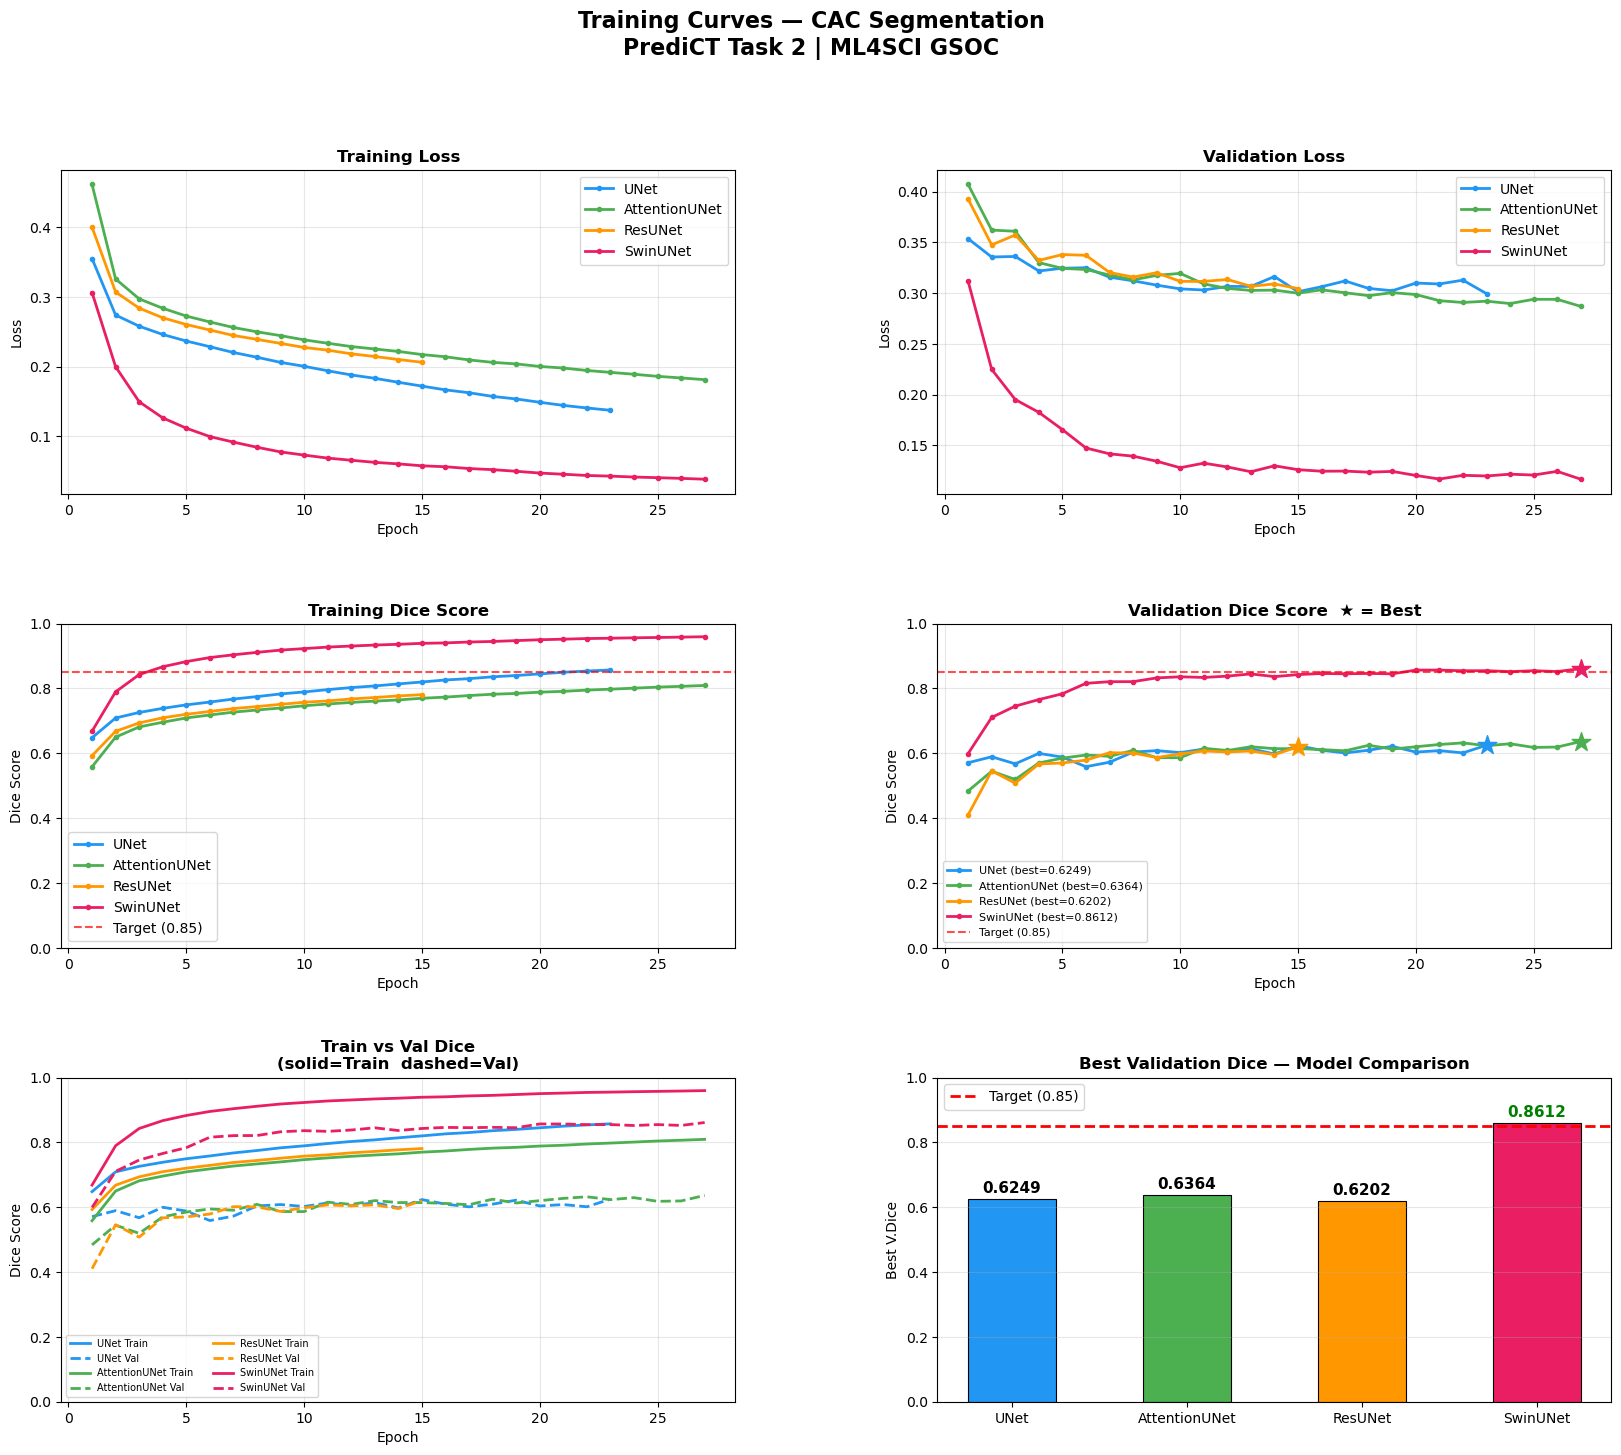

✅ Uploaded → s3://coca-dataset-3685/COCA_dataset/results/training_curves.png

✅ Plots saved to S3!

  FINAL RESULTS SUMMARY
     UNet            : V.Dice=0.6249  (23 epochs)
     AttentionUNet   : V.Dice=0.6364  (27 epochs)
     ResUNet         : V.Dice=0.6202  (15 epochs)
  🏆 SwinUNet        : V.Dice=0.8612  (27 epochs)


In [14]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def plot_training_curves(all_results):
    colors = {
        'UNet'         : '#2196F3',
        'AttentionUNet': '#4CAF50',
        'ResUNet'      : '#FF9800',
        'SwinUNet'     : '#E91E63'
    }

    fig = plt.figure(figsize=(20, 16))
    fig.suptitle(
        'Training Curves — CAC Segmentation\n'
        'PrediCT Task 2 | ML4SCI GSOC',
        fontsize=16, fontweight='bold', y=0.98
    )
    gs = gridspec.GridSpec(3, 2, figure=fig,
                           hspace=0.4, wspace=0.3)

    # ── Plot 1: Training Loss ──────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    for name, r in all_results.items():
        h      = r['history']
        epochs = range(1, len(h['train_loss']) + 1)
        ax1.plot(epochs, h['train_loss'],
                 color=colors[name], label=name,
                 linewidth=2, marker='o', markersize=3)
    ax1.set_title('Training Loss', fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # ── Plot 2: Validation Loss ────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    for name, r in all_results.items():
        h      = r['history']
        epochs = range(1, len(h['val_loss']) + 1)
        ax2.plot(epochs, h['val_loss'],
                 color=colors[name], label=name,
                 linewidth=2, marker='o', markersize=3)
    ax2.set_title('Validation Loss', fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # ── Plot 3: Training Dice ──────────────────────────────
    ax3 = fig.add_subplot(gs[1, 0])
    for name, r in all_results.items():
        h      = r['history']
        epochs = range(1, len(h['train_dice']) + 1)
        ax3.plot(epochs, h['train_dice'],
                 color=colors[name], label=name,
                 linewidth=2, marker='o', markersize=3)
    ax3.set_title('Training Dice Score', fontweight='bold')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Dice Score')
    ax3.set_ylim(0, 1)
    ax3.axhline(y=0.85, color='red', linestyle='--',
                alpha=0.7, label='Target (0.85)')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # ── Plot 4: Validation Dice ────────────────────────────
    ax4 = fig.add_subplot(gs[1, 1])
    for name, r in all_results.items():
        h       = r['history']
        epochs  = range(1, len(h['val_dice']) + 1)
        v_dice  = h['val_dice']
        best    = r['best_dice']
        ax4.plot(epochs, v_dice,
                 color=colors[name], linewidth=2,
                 marker='o', markersize=3,
                 label=f"{name} (best={best:.4f})")
        # Mark best point with star
        best_idx = v_dice.index(max(v_dice))
        ax4.scatter(best_idx + 1, max(v_dice),
                    color=colors[name], s=200,
                    zorder=5, marker='*')
    ax4.set_title('Validation Dice Score  ★ = Best',
                  fontweight='bold')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Dice Score')
    ax4.set_ylim(0, 1)
    ax4.axhline(y=0.85, color='red', linestyle='--',
                alpha=0.7, label='Target (0.85)')
    ax4.legend(fontsize=8)
    ax4.grid(True, alpha=0.3)

    # ── Plot 5: Train vs Val Dice per model ───────────────
    ax5 = fig.add_subplot(gs[2, 0])
    for name, r in all_results.items():
        h = r['history']
        ep_train = range(1, len(h['train_dice']) + 1)
        ep_val   = range(1, len(h['val_dice'])   + 1)
        ax5.plot(ep_train, h['train_dice'],
                 color=colors[name], linewidth=2,
                 linestyle='-',
                 label=f"{name} Train")
        ax5.plot(ep_val, h['val_dice'],
                 color=colors[name], linewidth=2,
                 linestyle='--',
                 label=f"{name} Val")
    ax5.set_title('Train vs Val Dice\n'
                  '(solid=Train  dashed=Val)',
                  fontweight='bold')
    ax5.set_xlabel('Epoch')
    ax5.set_ylabel('Dice Score')
    ax5.set_ylim(0, 1)
    ax5.legend(fontsize=7, ncol=2)
    ax5.grid(True, alpha=0.3)

    # ── Plot 6: Best V.Dice Bar Chart ─────────────────────
    ax6 = fig.add_subplot(gs[2, 1])
    names      = list(all_results.keys())
    best_dices = [all_results[n]['best_dice'] for n in names]
    bar_colors = [colors[n] for n in names]
    bars = ax6.bar(names, best_dices,
                   color=bar_colors,
                   edgecolor='black',
                   linewidth=0.8, width=0.5)
    ax6.axhline(y=0.85, color='red', linestyle='--',
                linewidth=2, label='Target (0.85)')
    ax6.set_title('Best Validation Dice — Model Comparison',
                  fontweight='bold')
    ax6.set_ylabel('Best V.Dice')
    ax6.set_ylim(0, 1)
    ax6.legend()
    ax6.grid(True, alpha=0.3, axis='y')
    # Value labels on bars
    for bar, val in zip(bars, best_dices):
        color = 'green' if val >= 0.85 else 'black'
        ax6.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f'{val:.4f}',
            ha='center', va='bottom',
            fontweight='bold', fontsize=11,
            color=color
        )

    # ── Save & Show ───────────────────────────────────────
    plt.savefig('/tmp/training_curves.png',
                dpi=150, bbox_inches='tight',
                facecolor='white')
    plt.show()
    plt.close()

    # Upload to S3
    upload_file('/tmp/training_curves.png',
                'results/training_curves.png')

    # Print summary
    print("\n✅ Plots saved to S3!")
    print(f"\n{'='*45}")
    print("  FINAL RESULTS SUMMARY")
    print(f"{'='*45}")
    for name, r in all_results.items():
        status = '🏆' if r['best_dice'] >= 0.85 else '  '
        epochs = len(r['history']['val_dice'])
        print(f"  {status} {name:15s} : "
              f"V.Dice={r['best_dice']:.4f}  "
              f"({epochs} epochs)")
    print(f"{'='*45}")


# ── Run ────────────────────────────────────────────────────
plot_training_curves(all_results)

In [15]:
#Retraing with improved parameters 

In [1]:
import torch
import subprocess

result = subprocess.run(
    ['nvidia-smi'], capture_output=True, text=True
)
print(result.stdout)
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
print(f"GPU     : {torch.cuda.get_device_name(0)}")
device = torch.device('cuda')
print(f"\n✅ GPU ready")

/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Sun Mar 29 09:15:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.211.01             Driver Version: 570.211.01     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       On  |   00000000:00:1E.0 Off |                    0 |
| N/A   26C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
print("kernel is alive!")
import torch
print(f"PyTorch : {torch.__version__}")
print(f"Device  : {device}")

kernel is alive!
PyTorch : 2.6.0+cu124
Device  : cuda


In [3]:
!pip install nibabel -q
print("✅ Done")

✅ Done


In [4]:
import os
import io
import time
import random
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
import boto3
import torchvision.transforms.functional as TF

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy.ndimage import zoom as nd_zoom
from torch.cuda.amp import autocast, GradScaler
# ── S3 Configuration ───────────────────────────────────────
BUCKET    = "coca-dataset-3685"
S3_PREFIX = "COCA_dataset"
LOCAL_DIR = "/tmp/coca_cache"
os.makedirs(LOCAL_DIR, exist_ok=True)

s3 = boto3.client('s3', region_name='ap-south-1')
device = torch.device('cuda')

def s3_key(relative_path):
    return f"{S3_PREFIX}/{relative_path}"

def download_npy(relative_path):
    local_path = os.path.join(
        LOCAL_DIR,
        relative_path.replace('/', '_')
    )
    if os.path.exists(local_path):
        return np.load(local_path)
    obj  = s3.get_object(
        Bucket=BUCKET, Key=s3_key(relative_path)
    )
    data = np.load(io.BytesIO(obj['Body'].read()))
    np.save(local_path, data)
    return data

def download_csv(relative_path):
    obj = s3.get_object(
        Bucket=BUCKET, Key=s3_key(relative_path)
    )
    return pd.read_csv(io.BytesIO(obj['Body'].read()))

def upload_file(local_path, s3_relative_path):
    s3.upload_file(
        local_path, BUCKET,
        s3_key(s3_relative_path)
    )
    print(f"✅ Uploaded → s3://{BUCKET}/"
          f"{s3_key(s3_relative_path)}")

# Test connection
response = s3.list_objects_v2(
    Bucket=BUCKET,
    Prefix=S3_PREFIX + '/',
    Delimiter='/', MaxKeys=10
)
folders = [
    p['Prefix']
    for p in response.get('CommonPrefixes', [])
]
print("S3 folders:")
for f in folders:
    print(f"  {f}")
print(f"\n✅ S3 connected")

S3 folders:
  COCA_dataset/Gated_release_final/
  COCA_dataset/deidentified_nongated/
  COCA_dataset/heart_segmentations/
  COCA_dataset/models/
  COCA_dataset/models_v2/
  COCA_dataset/preprocessed_cache/
  COCA_dataset/results/
  COCA_dataset/splits/

✅ S3 connected


In [5]:
train_df = download_csv("splits/heart_train.csv")
val_df   = download_csv("splits/heart_val.csv")
test_df  = download_csv("splits/heart_test.csv")

heart_train = train_df['patient_id']\
    .astype(str).tolist()
heart_val   = val_df['patient_id']\
    .astype(str).tolist()
heart_test  = test_df['patient_id']\
    .astype(str).tolist()

print(f"Train : {len(heart_train)} patients")
print(f"Val   : {len(heart_val)} patients")
print(f"Test  : {len(heart_test)} patients")
print(f"\n✅ Splits loaded")

Train : 156 patients
Val   : 20 patients
Test  : 20 patients

✅ Splits loaded


In [6]:
def apply_cardiac_window(ct_normalized):
    """
    Convert calcium-windowed [0,1] back to HU
    then apply cardiac soft tissue window.

    Calcium window  : center=200, width=600
                      range [-100, 500] HU
    Cardiac window  : center=40,  width=400
                      range [-160, 240] HU

    Cardiac window gives better contrast for:
    - Heart muscle  (40-60 HU)
    - Blood pool    (30-45 HU)
    - Pericardium   (borders)
    vs calcium window which emphasizes bone/calcium
    """
    # Reverse calcium normalization → HU
    ct_hu = ct_normalized * 600.0 - 100.0

    # Apply cardiac window
    hu_min = -160.0
    hu_max =  240.0
    ct_cardiac = np.clip(ct_hu, hu_min, hu_max)
    ct_cardiac = (ct_cardiac - hu_min) / \
                 (hu_max - hu_min)
    return ct_cardiac.astype(np.float32)


class HeartSegDatasetS3(Dataset):
    """
    2.5D Dataset with:
    - Cardiac HU windowing (fixed from calcium window)
    - 384×384 resolution (up from 256×256)
    - Stronger augmentation
    - Per-volume normalization
    """
    def __init__(self, patient_ids,
                 img_size=384,
                 augment=False):
        self.augment  = augment
        self.img_size = img_size
        self.slices   = []

        print(f"Building dataset from "
              f"{len(patient_ids)} patients...")

        for pid in patient_ids:
            try:
                ct   = download_npy(
                    f"preprocessed_cache/{pid}_img.npy"
                )
                mask = download_npy(
                    f"heart_segmentations/{pid}/"
                    f"heart_resampled.npy"
                )
            except Exception as e:
                print(f"  ⚠️  Skip {pid}: {e}")
                continue

            n_slices     = ct.shape[0]
            heart_slices = np.where(
                mask.sum(axis=(1,2)) > 0
            )[0]

            if len(heart_slices) == 0:
                continue

            z_min = max(0, heart_slices.min() - 5)
            z_max = min(n_slices-1,
                        heart_slices.max() + 5)

            for z in range(z_min, z_max + 1):
                self.slices.append(
                    (str(pid), z, n_slices)
                )

        print(f"Total slices : {len(self.slices)}")

    def __len__(self):
        return len(self.slices)

    def __getitem__(self, idx):
        pid, z, n_slices = self.slices[idx]

        ct   = download_npy(
            f"preprocessed_cache/{pid}_img.npy"
        )
        mask = download_npy(
            f"heart_segmentations/{pid}/"
            f"heart_resampled.npy"
        )

        # ── Fix 1: Cardiac HU windowing ───────────
        ct = apply_cardiac_window(ct)

        # ── Fix 2: Per-volume normalization ───────
        mean = ct[ct > 0.05].mean() \
               if (ct > 0.05).sum() > 0 else 0.5
        std  = ct[ct > 0.05].std() \
               if (ct > 0.05).sum() > 0 else 0.2
        ct   = (ct - mean) / (std + 1e-8)
        ct   = np.clip(ct, -3, 3)
        ct   = (ct + 3) / 6.0  # back to [0,1]
        ct   = ct.astype(np.float32)

        # ── 2.5D slice stacking ───────────────────
        z_prev = max(0, z - 1)
        z_next = min(n_slices - 1, z + 1)

        img = np.stack([
            ct[z_prev], ct[z], ct[z_next]
        ], axis=0).astype(np.float32)
        msk = mask[z].astype(np.float32)

        img_t = torch.FloatTensor(img)
        msk_t = torch.FloatTensor(msk).unsqueeze(0)

        # ── Fix 3: 384×384 resolution ─────────────
        img_t = F.interpolate(
            img_t.unsqueeze(0),
            size=(self.img_size, self.img_size),
            mode='bilinear', align_corners=False
        ).squeeze(0)
        msk_t = F.interpolate(
            msk_t.unsqueeze(0),
            size=(self.img_size, self.img_size),
            mode='nearest'
        ).squeeze(0)

        # ── Fix 4: Stronger augmentation ──────────
        if self.augment:
            # Random horizontal flip
            if torch.rand(1) > 0.5:
                img_t = torch.flip(img_t, dims=[2])
                msk_t = torch.flip(msk_t, dims=[2])

            # Random vertical flip
            if torch.rand(1) > 0.5:
                img_t = torch.flip(img_t, dims=[1])
                msk_t = torch.flip(msk_t, dims=[1])

            # Random rotation ±20 degrees
            if torch.rand(1) > 0.4:
                angle = float(
                    (torch.rand(1) - 0.5) * 40
                )
                img_t = TF.rotate(
                    img_t, angle,
                    interpolation=TF.InterpolationMode
                    .BILINEAR
                )
                msk_t = TF.rotate(
                    msk_t, angle,
                    interpolation=TF.InterpolationMode
                    .NEAREST
                )

            # Random brightness
            if torch.rand(1) > 0.5:
                factor = 0.7 + torch.rand(1) * 0.6
                img_t  = torch.clamp(
                    img_t * factor, 0, 1
                )

            # Random contrast
            if torch.rand(1) > 0.5:
                mean_v = img_t.mean()
                factor = 0.7 + torch.rand(1) * 0.6
                img_t  = torch.clamp(
                    (img_t - mean_v) * factor
                    + mean_v, 0, 1
                )

            # Gaussian noise
            if torch.rand(1) > 0.6:
                noise = torch.randn_like(img_t) \
                        * 0.02
                img_t = torch.clamp(
                    img_t + noise, 0, 1
                )

            # Gaussian blur
            if torch.rand(1) > 0.7:
                img_t = TF.gaussian_blur(
                    img_t, kernel_size=[3, 3],
                    sigma=[0.1, 1.0]
                )

        return {
            'image'      : img_t,
            'mask'       : msk_t,
            'patient_id' : pid,
            'slice_idx'  : z
        }

print("✅ Updated Dataset class defined")
print(f"   Cardiac HU windowing : ✅")
print(f"   Per-volume normalization : ✅")
print(f"   Resolution : 384×384 ✅")
print(f"   Strong augmentation : ✅")

✅ Updated Dataset class defined
   Cardiac HU windowing : ✅
   Per-volume normalization : ✅
   Resolution : 384×384 ✅
   Strong augmentation : ✅


In [7]:
IMG_SIZE = 384

# ── Shared components ──────────────────────────────────────
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3,
                      padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
            nn.Conv2d(out_ch, out_ch, 3,
                      padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)


# ── Model 1: UNet ──────────────────────────────────────────
class UNet(nn.Module):
    def __init__(self, in_channels=3,
                 out_channels=1,
                 features=[64,128,256,512],
                 dropout=0.1):
        super().__init__()
        self.downs  = nn.ModuleList()
        self.ups    = nn.ModuleList()
        self.pool   = nn.MaxPool2d(2)
        ch = in_channels
        for feat in features:
            self.downs.append(
                DoubleConv(ch, feat, dropout)
            )
            ch = feat
        self.bottleneck = DoubleConv(
            features[-1], features[-1]*2, dropout
        )
        for feat in reversed(features):
            self.ups.append(
                nn.ConvTranspose2d(
                    feat*2, feat, 2, stride=2
                )
            )
            self.ups.append(
                DoubleConv(feat*2, feat, dropout)
            )
        self.final = nn.Conv2d(
            features[0], out_channels, 1
        )

    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x)
            skips.append(x)
            x = self.pool(x)
        x = self.bottleneck(x)
        skips = skips[::-1]
        for i in range(0, len(self.ups), 2):
            x    = self.ups[i](x)
            skip = skips[i//2]
            if x.shape != skip.shape:
                x = F.interpolate(
                    x, size=skip.shape[2:],
                    mode='bilinear',
                    align_corners=False
                )
            x = torch.cat([skip, x], dim=1)
            x = self.ups[i+1](x)
        return self.final(x)


# ── Model 2: Attention UNet ────────────────────────────────
class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, 1, bias=False),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, 1, bias=False),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, 1, bias=False),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        if g1.shape != x1.shape:
            g1 = F.interpolate(
                g1, size=x1.shape[2:],
                mode='bilinear',
                align_corners=False
            )
        return x * self.psi(self.relu(g1 + x1))


class AttentionUNet(nn.Module):
    def __init__(self, in_channels=3,
                 out_channels=1,
                 features=[64,128,256,512],
                 dropout=0.1):
        super().__init__()
        self.downs      = nn.ModuleList()
        self.ups        = nn.ModuleList()
        self.attentions = nn.ModuleList()
        self.pool       = nn.MaxPool2d(2)
        ch = in_channels
        for feat in features:
            self.downs.append(
                DoubleConv(ch, feat, dropout)
            )
            ch = feat
        self.bottleneck = DoubleConv(
            features[-1], features[-1]*2, dropout
        )
        for feat in reversed(features):
            self.ups.append(
                nn.ConvTranspose2d(
                    feat*2, feat, 2, stride=2
                )
            )
            self.ups.append(
                DoubleConv(feat*2, feat, dropout)
            )
            self.attentions.append(
                AttentionGate(feat, feat, feat//2)
            )
        self.final = nn.Conv2d(
            features[0], out_channels, 1
        )

    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x)
            skips.append(x)
            x = self.pool(x)
        x     = self.bottleneck(x)
        skips = skips[::-1]
        for i in range(0, len(self.ups), 2):
            x    = self.ups[i](x)
            skip = skips[i//2]
            skip = self.attentions[i//2](x, skip)
            if x.shape != skip.shape:
                x = F.interpolate(
                    x, size=skip.shape[2:],
                    mode='bilinear',
                    align_corners=False
                )
            x = torch.cat([skip, x], dim=1)
            x = self.ups[i+1](x)
        return self.final(x)


# ── Model 3: ResUNet ───────────────────────────────────────
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3,
                      padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
            nn.Conv2d(out_ch, out_ch, 3,
                      padding=1, bias=False),
            nn.BatchNorm2d(out_ch)
        )
        self.skip = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch)
        ) if in_ch != out_ch else nn.Identity()
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(
            self.conv(x) + self.skip(x)
        )


class ResUNet(nn.Module):
    def __init__(self, in_channels=3,
                 out_channels=1,
                 features=[64,128,256,512],
                 dropout=0.1):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups   = nn.ModuleList()
        self.pool  = nn.MaxPool2d(2)
        ch = in_channels
        for feat in features:
            self.downs.append(
                ResBlock(ch, feat, dropout)
            )
            ch = feat
        self.bottleneck = ResBlock(
            features[-1], features[-1]*2, dropout
        )
        for feat in reversed(features):
            self.ups.append(
                nn.ConvTranspose2d(
                    feat*2, feat, 2, stride=2
                )
            )
            self.ups.append(
                ResBlock(feat*2, feat, dropout)
            )
        self.final = nn.Conv2d(
            features[0], out_channels, 1
        )

    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x)
            skips.append(x)
            x = self.pool(x)
        x     = self.bottleneck(x)
        skips = skips[::-1]
        for i in range(0, len(self.ups), 2):
            x    = self.ups[i](x)
            skip = skips[i//2]
            if x.shape != skip.shape:
                x = F.interpolate(
                    x, size=skip.shape[2:],
                    mode='bilinear',
                    align_corners=False
                )
            x = torch.cat([skip, x], dim=1)
            x = self.ups[i+1](x)
        return self.final(x)


# ── Swin Transformer components ────────────────────────────
class WindowAttention(nn.Module):
    def __init__(self, dim, window_size,
                 num_heads, dropout=0.0):
        super().__init__()
        self.dim         = dim
        self.window_size = window_size
        self.num_heads   = num_heads
        head_dim         = dim // num_heads
        self.scale       = head_dim ** -0.5
        self.qkv         = nn.Linear(
            dim, dim*3, bias=False
        )
        self.proj      = nn.Linear(dim, dim)
        self.attn_drop = nn.Dropout(dropout)
        self.proj_drop = nn.Dropout(dropout)

        self.relative_position_bias_table = \
            nn.Parameter(
                torch.zeros(
                    (2*window_size-1)**2,
                    num_heads
                )
            )
        nn.init.trunc_normal_(
            self.relative_position_bias_table,
            std=0.02
        )
        coords_h    = torch.arange(window_size)
        coords_w    = torch.arange(window_size)
        coords      = torch.stack(
            torch.meshgrid(
                coords_h, coords_w, indexing='ij'
            )
        )
        coords_flat = torch.flatten(coords, 1)
        relative    = (coords_flat[:,:,None] -
                       coords_flat[:,None,:])
        relative    = relative.permute(1,2,0)
        relative[:,:,0] += window_size - 1
        relative[:,:,1] += window_size - 1
        relative[:,:,0] *= 2*window_size - 1
        self.register_buffer(
            'relative_position_index',
            relative.sum(-1)
        )

    def forward(self, x):
        B_, N, C = x.shape
        qkv = self.qkv(x).reshape(
            B_, N, 3, self.num_heads,
            C // self.num_heads
        ).permute(2,0,3,1,4)
        q, k, v = qkv.unbind(0)
        attn    = (q * self.scale) @ \
                  k.transpose(-2,-1)
        bias    = self.relative_position_bias_table[
            self.relative_position_index.view(-1)
        ].view(
            self.window_size**2,
            self.window_size**2, -1
        ).permute(2,0,1).unsqueeze(0)
        attn = (attn + bias).softmax(dim=-1)
        attn = self.attn_drop(attn)
        x    = (attn @ v).transpose(1,2)\
                         .reshape(B_, N, C)
        return self.proj_drop(self.proj(x))


def window_partition(x, window_size):
    B, H, W, C = x.shape
    x = x.view(
        B, H//window_size, window_size,
        W//window_size, window_size, C
    )
    return x.permute(0,1,3,2,4,5)\
             .contiguous()\
             .view(-1, window_size, window_size, C)


def window_reverse(windows, window_size, H, W):
    B = int(
        windows.shape[0] / (H*W/window_size**2)
    )
    x = windows.view(
        B, H//window_size, W//window_size,
        window_size, window_size, -1
    )
    return x.permute(0,1,3,2,4,5)\
             .contiguous().view(B, H, W, -1)


class SwinTransformerBlock(nn.Module):
    def __init__(self, dim, num_heads,
                 window_size=6, shift_size=0,
                 mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        self.window_size = window_size
        self.shift_size  = shift_size
        self.norm1       = nn.LayerNorm(dim)
        self.attn        = WindowAttention(
            dim, window_size, num_heads, dropout
        )
        self.norm2     = nn.LayerNorm(dim)
        mlp_hidden     = int(dim * mlp_ratio)
        self.mlp       = nn.Sequential(
            nn.Linear(dim, mlp_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x, H, W):
        B, L, C  = x.shape
        shortcut = x
        x = self.norm1(x).view(B, H, W, C)
        if self.shift_size > 0:
            x = torch.roll(
                x,
                shifts=(-self.shift_size,
                        -self.shift_size),
                dims=(1,2)
            )
        x_win = window_partition(
            x, self.window_size
        ).view(-1, self.window_size**2, C)
        x_win = self.attn(x_win).view(
            -1, self.window_size,
            self.window_size, C
        )
        x = window_reverse(
            x_win, self.window_size, H, W
        )
        if self.shift_size > 0:
            x = torch.roll(
                x,
                shifts=(self.shift_size,
                        self.shift_size),
                dims=(1,2)
            )
        x = shortcut + x.view(B, H*W, C)
        return x + self.mlp(self.norm2(x))


# ── Model 4: SwinUNet (fixed for 384×384) ─────────────────
class SwinUNet(nn.Module):
    """
    Swin-UNet for 384×384 input.
    patch_size=8 → 48×48 tokens
    window_size=6 → divides 48 evenly
    embed_dim=96
    """
    def __init__(self, in_channels=3,
                 out_channels=1,
                 img_size=384,
                 patch_size=8,
                 embed_dim=96,
                 window_size=6,
                 dropout=0.1):
        super().__init__()
        self.patch_size = patch_size

        # 384 / 8 = 48 tokens per side
        self.patch_embed = nn.Sequential(
            nn.Conv2d(
                in_channels, embed_dim,
                kernel_size=patch_size,
                stride=patch_size
            ),
            nn.Flatten(2)
        )
        self.patch_norm = nn.LayerNorm(embed_dim)

        def make_stage(dim, depth, ws, drop):
            return nn.ModuleList([
                SwinTransformerBlock(
                    dim=dim,
                    num_heads=max(1, dim//32),
                    window_size=ws,
                    shift_size=0 if i%2==0
                               else ws//2,
                    dropout=drop
                )
                for i in range(depth)
            ])

        d  = embed_dim
        ws = window_size

        # Encoder stages
        # 48×48 → enc1
        self.enc1  = make_stage(d,   2, ws, dropout)
        self.down1 = nn.Sequential(
            nn.LayerNorm(d),
            nn.Linear(d, d*2, bias=False)
        )
        # 24×24 → enc2
        self.enc2  = make_stage(d*2, 2, ws, dropout)
        self.down2 = nn.Sequential(
            nn.LayerNorm(d*2),
            nn.Linear(d*2, d*4, bias=False)
        )
        # 12×12 → enc3
        self.enc3  = make_stage(d*4, 6, ws, dropout)
        self.down3 = nn.Sequential(
            nn.LayerNorm(d*4),
            nn.Linear(d*4, d*8, bias=False)
        )
        # 6×6 → bottleneck
        self.bottleneck = make_stage(
            d*8, 2, ws, dropout
        )

        # Decoder
        self.up3       = nn.Linear(
            d*8, d*4, bias=False
        )
        self.dec3_proj = nn.Linear(
            d*8, d*4, bias=False
        )
        self.dec3      = make_stage(
            d*4, 2, ws, dropout
        )

        self.up2       = nn.Linear(
            d*4, d*2, bias=False
        )
        self.dec2_proj = nn.Linear(
            d*4, d*2, bias=False
        )
        self.dec2      = make_stage(
            d*2, 2, ws, dropout
        )

        self.up1       = nn.Linear(
            d*2, d, bias=False
        )
        self.dec1_proj = nn.Linear(
            d*2, d, bias=False
        )
        self.dec1      = make_stage(
            d, 2, ws, dropout
        )

        self.final_expand = nn.Sequential(
            nn.LayerNorm(d),
            nn.Linear(
                d, patch_size*patch_size*d
            ),
            nn.GELU()
        )
        self.final_conv = nn.Conv2d(
            d, out_channels, 1
        )

    def _run_stage(self, x, stage, H, W):
        for block in stage:
            x = block(x, H, W)
        return x

    def _downsample(self, x, down, H, W):
        """Downsample tokens 2x using linear proj."""
        B = x.shape[0]
        x = down(x)   # (B, H*W, C*2)
        # Use interpolate for reliable downsampling
        C = x.shape[-1]
        x = x.reshape(B, H, W, C)\
              .permute(0, 3, 1, 2)   # (B,C,H,W)
        x = F.avg_pool2d(x, 2)       # (B,C,H/2,W/2)
        x = x.permute(0, 2, 3, 1)\
              .reshape(B, (H//2)*(W//2), C)
        return x

    def _upsample_cat(self, x, skip,
                       h_in, w_in,
                       h_out, w_out):
        B = x.shape[0]
        C = x.shape[-1]
        x = x.reshape(B, h_in, w_in, C)\
              .permute(0, 3, 1, 2)
        x = F.interpolate(
            x, size=(h_out, w_out),
            mode='bilinear', align_corners=False
        )
        x = x.permute(0, 2, 3, 1)\
              .reshape(B, h_out*w_out, C)
        return torch.cat([x, skip], dim=-1)

    def forward(self, x):
        B, C, H, W = x.shape

        feat = self.patch_embed(x)\
                   .permute(0, 2, 1)
        feat = self.patch_norm(feat)

        ps = self.patch_size
        h  = H // ps   # 48
        w  = W // ps   # 48

        # Encoder
        e1 = self._run_stage(
            feat, self.enc1, h, w
        )                              # 48×48
        d1 = self._downsample(
            e1, self.down1, h, w
        )                              # 24×24

        e2 = self._run_stage(
            d1, self.enc2, h//2, w//2
        )                              # 24×24
        d2 = self._downsample(
            e2, self.down2, h//2, w//2
        )                              # 12×12

        e3 = self._run_stage(
            d2, self.enc3, h//4, w//4
        )                              # 12×12
        d3 = self._downsample(
            e3, self.down3, h//4, w//4
        )                              # 6×6

        bt = self._run_stage(
            d3, self.bottleneck, h//8, w//8
        )                              # 6×6

        # Decoder
        cat3 = self._upsample_cat(
            self.up3(bt), e3,
            h//8, w//8, h//4, w//4
        )
        d_3 = self._run_stage(
            self.dec3_proj(cat3),
            self.dec3, h//4, w//4
        )

        cat2 = self._upsample_cat(
            self.up2(d_3), e2,
            h//4, w//4, h//2, w//2
        )
        d_2 = self._run_stage(
            self.dec2_proj(cat2),
            self.dec2, h//2, w//2
        )

        cat1 = self._upsample_cat(
            self.up1(d_2), e1,
            h//2, w//2, h, w
        )
        d_1 = self._run_stage(
            self.dec1_proj(cat1),
            self.dec1, h, w
        )

        # Reconstruct pixels
        out = self.final_expand(d_1)
        out = out.reshape(
            B, h, w, ps, ps, -1
        ).permute(0,1,3,2,4,5)\
         .contiguous()\
         .reshape(B, h*ps, w*ps, -1)\
         .permute(0, 3, 1, 2)
        out = self.final_conv(out)

        if out.shape[-2:] != (H, W):
            out = F.interpolate(
                out, size=(H, W),
                mode='bilinear',
                align_corners=False
            )
        return out


# ── Model 5: UNet++ (Fixed) ────────────────────────────────
class UNetPlusPlus(nn.Module):
    """
    UNet++ with dense skip connections.
    Fixed channel dimensions for correct
    concatenation at each dense node.
    """
    def __init__(self, in_channels=3,
                 out_channels=1,
                 features=[64,128,256,512],
                 dropout=0.1):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        nb        = features

        # ── Encoder X_{i,0} ───────────────────────
        self.conv0_0 = DoubleConv(
            in_channels, nb[0], dropout
        )
        self.conv1_0 = DoubleConv(
            nb[0], nb[1], dropout
        )
        self.conv2_0 = DoubleConv(
            nb[1], nb[2], dropout
        )
        self.conv3_0 = DoubleConv(
            nb[2], nb[3], dropout
        )

        # ── Upsampling ops ─────────────────────────
        # Each up[i] takes nb[i+1] → nb[i+1]
        # (no channel change, just spatial 2x)
        self.up1_0 = nn.Upsample(
            scale_factor=2, mode='bilinear',
            align_corners=True
        )
        self.up2_0 = nn.Upsample(
            scale_factor=2, mode='bilinear',
            align_corners=True
        )
        self.up3_0 = nn.Upsample(
            scale_factor=2, mode='bilinear',
            align_corners=True
        )

        # ── Dense nodes ────────────────────────────
        # X_{0,1}: cat(X_{0,0}, up(X_{1,0}))
        #          = nb[0] + nb[1]
        self.conv0_1 = DoubleConv(
            nb[0] + nb[1], nb[0], dropout
        )

        # X_{1,1}: cat(X_{1,0}, up(X_{2,0}))
        #          = nb[1] + nb[2]
        self.conv1_1 = DoubleConv(
            nb[1] + nb[2], nb[1], dropout
        )

        # X_{0,2}: cat(X_{0,0}, X_{0,1}, up(X_{1,1}))
        #          = nb[0] + nb[0] + nb[1]
        self.conv0_2 = DoubleConv(
            nb[0]*2 + nb[1], nb[0], dropout
        )

        # X_{2,1}: cat(X_{2,0}, up(X_{3,0}))
        #          = nb[2] + nb[3]
        self.conv2_1 = DoubleConv(
            nb[2] + nb[3], nb[2], dropout
        )

        # X_{1,2}: cat(X_{1,0}, X_{1,1}, up(X_{2,1}))
        #          = nb[1] + nb[1] + nb[2]
        self.conv1_2 = DoubleConv(
            nb[1]*2 + nb[2], nb[1], dropout
        )

        # X_{0,3}: cat(X_{0,0},X_{0,1},X_{0,2},up(X_{1,2}))
        #          = nb[0]*3 + nb[1]
        self.conv0_3 = DoubleConv(
            nb[0]*3 + nb[1], nb[0], dropout
        )

        self.final = nn.Conv2d(
            nb[0], out_channels, 1
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(
                    m.weight,
                    mode='fan_out',
                    nonlinearity='relu'
                )
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _up_cat(self, x_up, *skips):
        """Upsample x_up to match skip size then cat."""
        x_up = F.interpolate(
            x_up, size=skips[0].shape[2:],
            mode='bilinear', align_corners=True
        )
        return torch.cat([*skips, x_up], dim=1)

    def forward(self, x):
        # Encoder
        x0_0 = self.conv0_0(x)
        x1_0 = self.conv1_0(self.pool(x0_0))
        x2_0 = self.conv2_0(self.pool(x1_0))
        x3_0 = self.conv3_0(self.pool(x2_0))

        # Dense connections
        # X_{0,1} = conv(cat(X_{0,0}, up(X_{1,0})))
        x0_1 = self.conv0_1(
            self._up_cat(x1_0, x0_0)
        )

        # X_{1,1} = conv(cat(X_{1,0}, up(X_{2,0})))
        x1_1 = self.conv1_1(
            self._up_cat(x2_0, x1_0)
        )

        # X_{0,2} = conv(cat(X_{0,0}, X_{0,1}, up(X_{1,1})))
        x0_2 = self.conv0_2(
            self._up_cat(x1_1, x0_0, x0_1)
        )

        # X_{2,1} = conv(cat(X_{2,0}, up(X_{3,0})))
        x2_1 = self.conv2_1(
            self._up_cat(x3_0, x2_0)
        )

        # X_{1,2} = conv(cat(X_{1,0}, X_{1,1}, up(X_{2,1})))
        x1_2 = self.conv1_2(
            self._up_cat(x2_1, x1_0, x1_1)
        )

        # X_{0,3} = conv(cat(X_{0,0},X_{0,1},X_{0,2},up(X_{1,2})))
        x0_3 = self.conv0_3(
            self._up_cat(x1_2, x0_0, x0_1, x0_2)
        )

        return self.final(x0_3)


# ── Test all 5 models ──────────────────────────────────────
dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE)\
             .to(device)

for name, ModelClass, kwargs in [
    ('UNet',         UNet,
     {'dropout': 0.1}),
    ('AttentionUNet',AttentionUNet,
     {'dropout': 0.1}),
    ('ResUNet',      ResUNet,
     {'dropout': 0.1}),
    ('SwinUNet',     SwinUNet,
     {'img_size': IMG_SIZE}),
    ('UNetPlusPlus', UNetPlusPlus,
     {'dropout': 0.1}),
]:
    m = ModelClass(**kwargs).to(device)
    o = m(dummy)
    n = sum(p.numel() for p in m.parameters())
    print(f"{name:15s} : {n/1e6:.1f}M params | "
          f"output {o.shape}")

print(f"\n✅ All 5 models defined and tested")

UNet            : 31.0M params | output torch.Size([2, 1, 384, 384])
AttentionUNet   : 31.4M params | output torch.Size([2, 1, 384, 384])
ResUNet         : 32.4M params | output torch.Size([2, 1, 384, 384])
SwinUNet        : 32.4M params | output torch.Size([2, 1, 384, 384])
UNetPlusPlus    : 8.9M params | output torch.Size([2, 1, 384, 384])

✅ All 5 models defined and tested


In [8]:
# ── Tversky + Focal Tversky Loss ──────────────────────────
class TverskyLoss(nn.Module):
    """
    Tversky Loss with α=0.3, β=0.7.
    Penalizes False Negatives more than
    False Positives — better for heart
    where missing tissue is worse than
    over-predicting.
    """
    def __init__(self, alpha=0.3,
                 beta=0.7, smooth=1.0):
        super().__init__()
        self.alpha  = alpha
        self.beta   = beta
        self.smooth = smooth

    def forward(self, pred, target):
        pred   = torch.sigmoid(pred)
        pred   = pred.view(-1)
        target = target.view(-1)
        TP = (pred * target).sum()
        FP = ((1-target) * pred).sum()
        FN = (target * (1-pred)).sum()
        tversky = (TP + self.smooth) / \
                  (TP + self.alpha*FP +
                   self.beta*FN + self.smooth)
        return 1 - tversky


class FocalTverskyLoss(nn.Module):
    """
    Focal Tversky Loss — adds focal mechanism
    to focus on hard-to-segment regions.
    gamma=1.5 works well for heart boundaries.
    """
    def __init__(self, alpha=0.3, beta=0.7,
                 gamma=1.5, smooth=1.0):
        super().__init__()
        self.alpha  = alpha
        self.beta   = beta
        self.gamma  = gamma
        self.smooth = smooth

    def forward(self, pred, target):
        pred   = torch.sigmoid(pred)
        pred   = pred.view(-1)
        target = target.view(-1)
        TP = (pred * target).sum()
        FP = ((1-target) * pred).sum()
        FN = (target * (1-pred)).sum()
        tversky = (TP + self.smooth) / \
                  (TP + self.alpha*FP +
                   self.beta*FN + self.smooth)
        return (1 - tversky) ** self.gamma


class CombinedLoss(nn.Module):
    """
    FocalTversky (70%) + BCE (30%)
    FocalTversky handles boundary/imbalance
    BCE provides pixel-level stability
    """
    def __init__(self):
        super().__init__()
        self.focal_tversky = FocalTverskyLoss(
            alpha=0.3, beta=0.7, gamma=1.5
        )
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, pred, target):
        return (0.7 * self.focal_tversky(
                    pred, target
                ) +
                0.3 * self.bce(pred, target))


def dice_score(pred, target, threshold=0.5):
    pred   = (torch.sigmoid(pred)
               > threshold).float()
    pred   = pred.view(-1)
    target = target.view(-1)
    inter  = (pred * target).sum()
    return (2.*inter + 1) / \
           (pred.sum() + target.sum() + 1)


# Define scaler ONCE before training loop
scaler = GradScaler()

def train_one_epoch(model, loader, optimizer,
                    criterion, device):
    model.train()
    total_loss = 0
    total_dice = 0

    for batch in loader:
        imgs  = batch['image'].to(device)
        masks = batch['mask'].to(device)
        optimizer.zero_grad()

        # ONLY CHANGE — wrap forward pass
        with autocast():
            preds = model(imgs)
            loss  = criterion(preds, masks)

        # ONLY CHANGE — use scaler instead of loss.backward()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), max_norm=1.0
        )
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        total_dice += dice_score(
            preds, masks
        ).item()

    return (total_loss/len(loader),
            total_dice/len(loader))


def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    total_dice = 0
    with torch.no_grad():
        for batch in loader:
            imgs  = batch['image'].to(device)
            masks = batch['mask'].to(device)
            preds = model(imgs)
            loss  = criterion(preds, masks)
            total_loss += loss.item()
            total_dice += dice_score(
                preds, masks
            ).item()
    return (total_loss/len(loader),
            total_dice/len(loader))


def train_model(model, model_name,
                train_loader, val_loader,
                n_epochs=80, lr=3e-4):
    """
    Train with:
    - LR warmup for first 5 epochs
    - Cosine annealing after warmup
    - Gradient clipping
    - Early stopping (patience=20)
    """
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr, weight_decay=1e-4
    )

    # ── LR Warmup + Cosine Annealing ──────────
    from torch.optim.lr_scheduler import (
        LinearLR, CosineAnnealingLR,
        SequentialLR
    )
    warmup = LinearLR(
        optimizer,
        start_factor=0.1,
        end_factor=1.0,
        total_iters=5
    )
    cosine = CosineAnnealingLR(
        optimizer,
        T_max=n_epochs-5,
        eta_min=1e-6
    )
    scheduler = SequentialLR(
        optimizer,
        schedulers=[warmup, cosine],
        milestones=[5]
    )

    criterion  = CombinedLoss()
    best_dice  = 0.0
    best_epoch = 0
    no_improve = 0
    history    = {
        'train_loss': [], 'val_loss': [],
        'train_dice': [], 'val_dice': [],
        'lr'        : []
    }
    local_path = f"/tmp/{model_name}_best.pth"

    print(f"\n{'='*65}")
    print(f"Training {model_name}")
    print(f"Epochs: {n_epochs} | LR: {lr} | "
          f"Loss: FocalTversky+BCE")
    print(f"{'='*65}")
    print(f"{'Ep':>4} | {'T.Loss':>7} | "
          f"{'V.Loss':>7} | {'T.Dice':>7} | "
          f"{'V.Dice':>7} | {'LR':>8} |")
    print("-" * 55)

    for epoch in range(1, n_epochs + 1):
        t_loss, t_dice = train_one_epoch(
            model, train_loader,
            optimizer, criterion, device
        )
        v_loss, v_dice = validate(
            model, val_loader, criterion, device
        )
        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step()

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_dice'].append(t_dice)
        history['val_dice'].append(v_dice)
        history['lr'].append(current_lr)

        is_best = v_dice > best_dice
        if is_best:
            best_dice  = v_dice
            best_epoch = epoch
            no_improve = 0
            torch.save({
                'epoch'      : epoch,
                'model_state': model.state_dict(),
                'best_dice'  : best_dice,
                'history'    : history,
                'model_name' : model_name
            }, local_path)
        else:
            no_improve += 1

        print(f"{epoch:4d} | {t_loss:7.4f} | "
              f"{v_loss:7.4f} | {t_dice:7.4f} | "
              f"{v_dice:7.4f} | "
              f"{current_lr:.2e} | "
              f"{'⭐' if is_best else ''}")

        if no_improve >= 20:
            print(f"\nEarly stopping @ epoch {epoch}"
                  f" — no improvement for 20 epochs")
            break

    # Upload to S3
    upload_file(
        local_path,
        f"models_v2/{model_name}_best.pth"
    )
    print(f"\nBest Val Dice : {best_dice:.4f} "
          f"@ epoch {best_epoch}")
    return model, history, best_dice


print("✅ Loss functions and training defined")
print(f"   FocalTverskyLoss : α=0.3, β=0.7, γ=1.5")
print(f"   LR warmup        : 5 epochs")
print(f"   Gradient clip    : max_norm=1.0")
print(f"   Early stopping   : patience=20")

✅ Loss functions and training defined
   FocalTverskyLoss : α=0.3, β=0.7, γ=1.5
   LR warmup        : 5 epochs
   Gradient clip    : max_norm=1.0
   Early stopping   : patience=20


/tmp/ipykernel_7089/1671996284.py:88: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [9]:
print("Building datasets from S3...")
print(f"Resolution : {IMG_SIZE}×{IMG_SIZE}")
print(f"Window     : Cardiac (center=40, width=400)\n")

train_dataset = HeartSegDatasetS3(
    heart_train, img_size=IMG_SIZE, augment=True
)
val_dataset = HeartSegDatasetS3(
    heart_val, img_size=IMG_SIZE, augment=False
)
test_dataset = HeartSegDatasetS3(
    heart_test, img_size=IMG_SIZE, augment=False
)

train_loader = DataLoader(
    train_dataset, batch_size=8,
    shuffle=True, num_workers=4,
    pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=8,
    shuffle=False, num_workers=4
)
test_loader = DataLoader(
    test_dataset, batch_size=8,
    shuffle=False, num_workers=4
)

batch = next(iter(train_loader))
print(f"Train slices : {len(train_dataset)}")
print(f"Val slices   : {len(val_dataset)}")
print(f"Test slices  : {len(test_dataset)}")
print(f"Batch image  : {batch['image'].shape}")
print(f"Batch mask   : {batch['mask'].shape}")
print(f"\n✅ DataLoaders ready")

Building datasets from S3...
Resolution : 384×384
Window     : Cardiac (center=40, width=400)

Building dataset from 156 patients...
  ⚠️  Skip 140: An error occurred (NoSuchKey) when calling the GetObject operation: The specified key does not exist.
  ⚠️  Skip 108: An error occurred (NoSuchKey) when calling the GetObject operation: The specified key does not exist.
  ⚠️  Skip 11: An error occurred (NoSuchKey) when calling the GetObject operation: The specified key does not exist.
  ⚠️  Skip 111: An error occurred (NoSuchKey) when calling the GetObject operation: The specified key does not exist.
  ⚠️  Skip 182: An error occurred (NoSuchKey) when calling the GetObject operation: The specified key does not exist.
  ⚠️  Skip 172: An error occurred (NoSuchKey) when calling the GetObject operation: The specified key does not exist.
  ⚠️  Skip 196: An error occurred (NoSuchKey) when calling the GetObject operation: The specified key does not exist.
  ⚠️  Skip 114: An error occurred (NoSuchK

In [10]:
# ── Load completed models from S3 ─────────────────────────
import torch
import boto3

all_results = {}

# Models already complete — load from S3
completed_models = [
    ('UNet', UNet(dropout=0.1)),
]

for model_name, model in completed_models:
    local = f'/tmp/{model_name}_best.pth'

    # Download from S3 if not in /tmp/
    if not os.path.exists(local):
        print(f"Downloading {model_name} from S3...")
        s3.download_file(
            BUCKET,
            s3_key(f"models_v2/{model_name}_best.pth"),
            local
        )

    ckpt = torch.load(local, map_location=device)
    model.load_state_dict(ckpt['model_state'])
    model = model.to(device)
    model.eval()

    all_results[model_name] = {
        'model'     : model,
        'history'   : ckpt.get('history', {}),
        'best_dice' : ckpt['best_dice']
    }
    print(f"✅ {model_name:15s} loaded — "
          f"V.Dice={ckpt['best_dice']:.4f} "
          f"@ epoch {ckpt['epoch']}")

print(f"\n✅ Completed models loaded!")

✅ UNet            loaded — V.Dice=0.5815 @ epoch 42

✅ Completed models loaded!


In [ ]:
# ── Train only incomplete models ──────────────────────────
models_to_train = [
    ('AttentionUNet',
     AttentionUNet(dropout=0.1).to(device)),
    ('ResUNet',
     ResUNet(dropout=0.1).to(device)),
    ('SwinUNet',
     SwinUNet(img_size=IMG_SIZE).to(device)),
    ('UNetPlusPlus',
     UNetPlusPlus(dropout=0.1).to(device)),
]

for model_name, model in models_to_train:
    n = sum(
        p.numel() for p in model.parameters()
    )
    print(f"\nStarting {model_name} "
          f"({n/1e6:.1f}M params)...")
    trained, history, best_dice = train_model(
        model, model_name,
        train_loader, val_loader,
        n_epochs=80
    )
    all_results[model_name] = {
        'model'     : trained,
        'history'   : history,
        'best_dice' : best_dice
    }

# ── Final summary ──────────────────────────────────────────
print(f"\n{'='*50}")
print("ALL MODELS COMPLETE")
print(f"{'='*50}")
for name, r in all_results.items():
    status = '✅' if r['best_dice'] >= 0.85 \
             else '⚠️ '
    print(f"  {status} {name:15s} : "
          f"{r['best_dice']:.4f}")


Starting AttentionUNet (31.4M params)...

Training AttentionUNet
Epochs: 80 | LR: 0.0003 | Loss: FocalTversky+BCE
  Ep |  T.Loss |  V.Loss |  T.Dice |  V.Dice |       LR |
-------------------------------------------------------


/tmp/ipykernel_7089/1671996284.py:102: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


In [ ]:
all_results = {}

models_to_train = [
    ('UNet',
     UNet(dropout=0.1).to(device)),
    ('AttentionUNet',
     AttentionUNet(dropout=0.1).to(device)),
    ('ResUNet',
     ResUNet(dropout=0.1).to(device)),
    ('SwinUNet',
     SwinUNet(img_size=IMG_SIZE).to(device)),
    ('UNetPlusPlus',
     UNetPlusPlus(dropout=0.1).to(device)),
]

for model_name, model in models_to_train:
    n = sum(
        p.numel() for p in model.parameters()
    )
    print(f"\nStarting {model_name} "
          f"({n/1e6:.1f}M params)...")

    trained, history, best_dice = train_model(
        model, model_name,
        train_loader, val_loader,
        n_epochs=80
    )
    all_results[model_name] = {
        'model'     : trained,
        'history'   : history,
        'best_dice' : best_dice
    }

print(f"\n{'='*50}")
print("ALL MODELS TRAINED")
print(f"{'='*50}")
for name, r in all_results.items():
    status = '✅' if r['best_dice'] >= 0.85 \
             else '⚠️ '
    print(f"  {status} {name:15s} : "
          f"{r['best_dice']:.4f}")